In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv('../data/processed/cleaned_online_news.csv')
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,6.386879
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,6.568078
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,7.313887
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,7.090910
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,6.226537


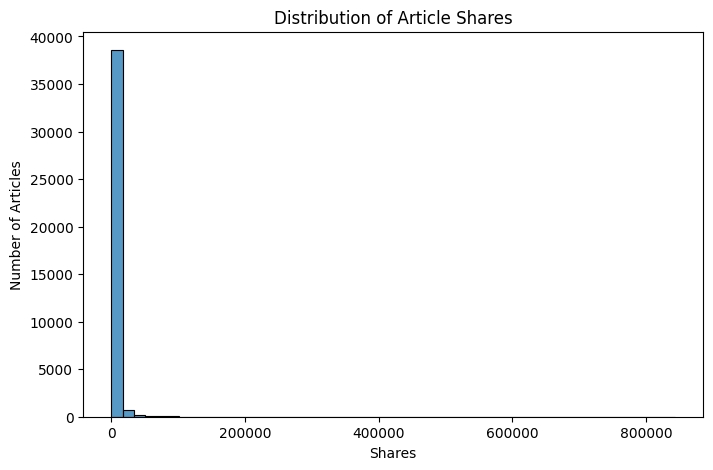

In [5]:
# Target Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['shares'], bins=50)
plt.title("Distribution of Article Shares")
plt.xlabel("Shares")
plt.ylabel("Number of Articles")
plt.show()

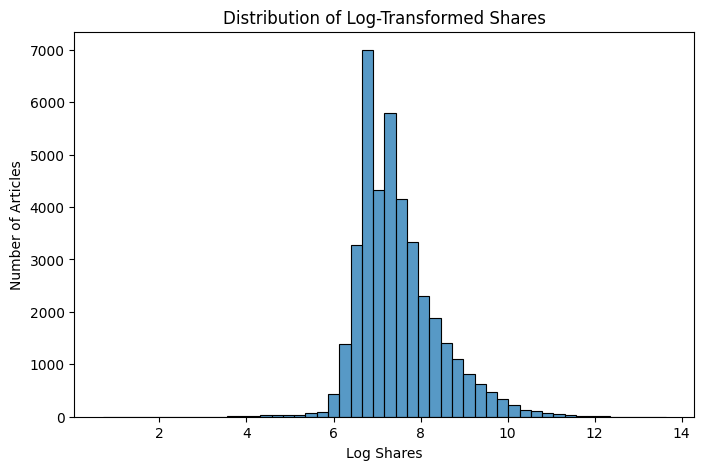

In [6]:
# Log-transformed shares distribution
plt.figure(figsize=(8,5))
sns.histplot(df["log_shares"], bins=50)
plt.title("Distribution of Log-Transformed Shares")
plt.xlabel("Log Shares")
plt.ylabel("Number of Articles")
plt.show()

In [7]:
# Average shares by article category
category_cols = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"
]

category_names = [
    "Lifestyle",
    "Entertainment",
    "Business",
    "Social Media",
    "Technology",
    "World"
]

category_avg = {}

for col, name in zip(category_cols, category_names):
    category_avg[name] = df[df[col] == 1]["shares"].mean()

category_avg_df = pd.DataFrame({
    "Category": category_avg.keys(),
    "Average Shares": category_avg.values()
}).sort_values(by="Average Shares", ascending=False)

category_avg_df

,Category,Average Shares
0,Lifestyle,3682.123392
3,Social Media,3629.383125
4,Technology,3072.283283
2,Business,3063.018536
1,Entertainment,2970.487034
5,World,2287.734069


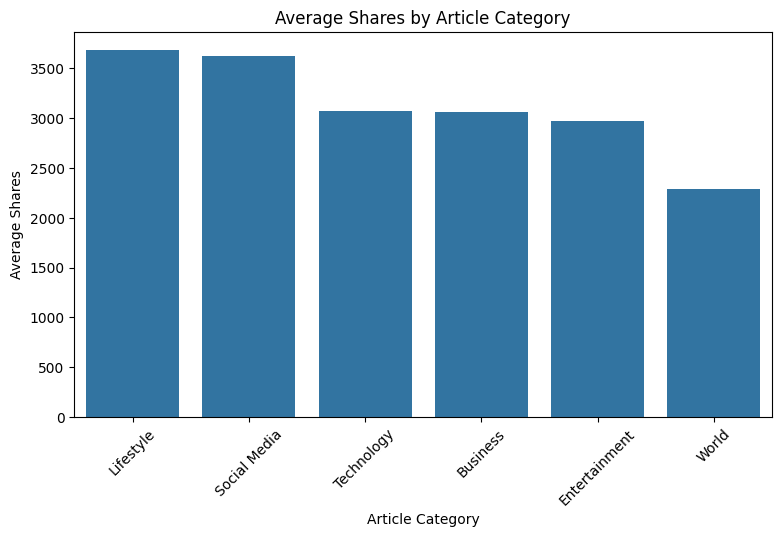

In [8]:
plt.figure(figsize=(9,5))
sns.barplot(data=category_avg_df, x="Category", y="Average Shares")
plt.title("Average Shares by Article Category")
plt.xlabel("Article Category")
plt.ylabel("Average Shares")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Average shares by weekday
weekday_cols = [
    "weekday_is_monday",
    "weekday_is_tuesday",
    "weekday_is_wednesday",
    "weekday_is_thursday",
    "weekday_is_friday",
    "weekday_is_saturday",
    "weekday_is_sunday"
]

weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_avg = {}

for col, name in zip(weekday_cols, weekday_names):
    weekday_avg[name] = df[df[col] == 1]["shares"].mean()

weekday_avg_df = pd.DataFrame({
    "Weekday": weekday_avg.keys(),
    "Average Shares": weekday_avg.values()
})

weekday_avg_df

,Weekday,Average Shares
0,Monday,3647.025822
1,Tuesday,3202.500677
2,Wednesday,3303.405380
3,Thursday,3178.599147
4,Friday,3285.181021
5,Saturday,4078.185079
6,Sunday,3746.740592


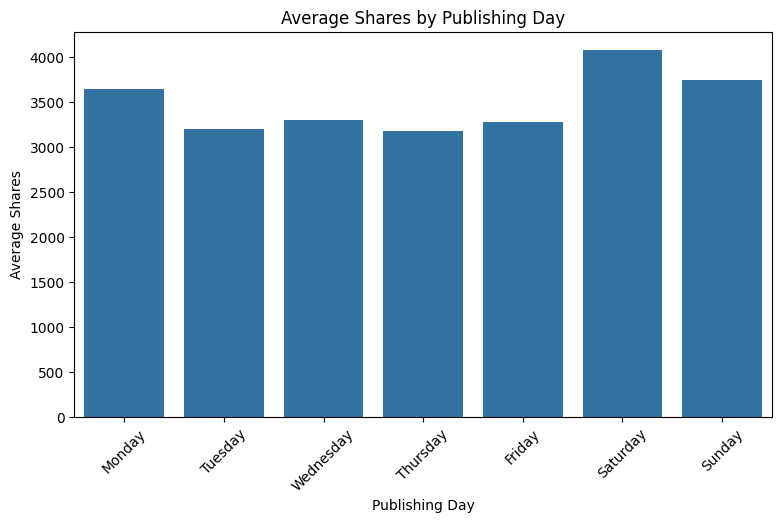

In [10]:
plt.figure(figsize=(9,5))
sns.barplot(data=weekday_avg_df, x="Weekday", y="Average Shares")
plt.title("Average Shares by Publishing Day")
plt.xlabel("Publishing Day")
plt.ylabel("Average Shares")
plt.xticks(rotation=45)
plt.show()

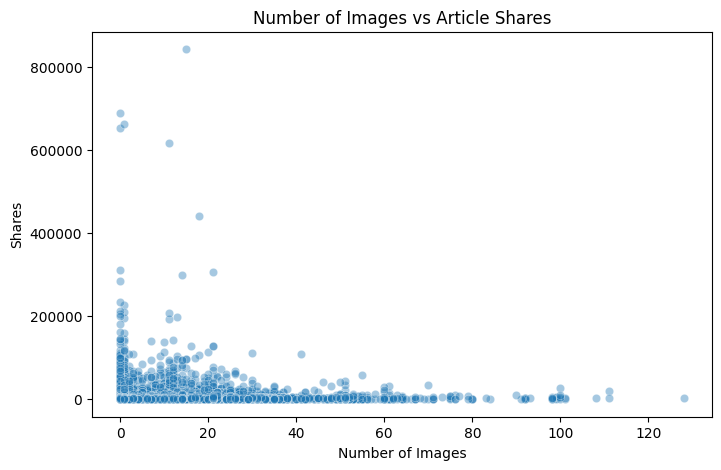

In [11]:
# Images vs shares
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="num_imgs", y="shares", alpha=0.4)
plt.title("Number of Images vs Article Shares")
plt.xlabel("Number of Images")
plt.ylabel("Shares")
plt.show()

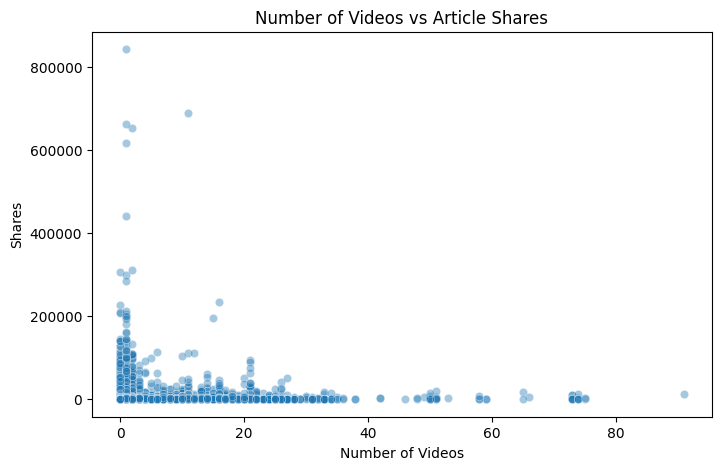

In [12]:
# Videos vs shares
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="num_videos", y="shares", alpha=0.4)
plt.title("Number of Videos vs Article Shares")
plt.xlabel("Number of Videos")
plt.ylabel("Shares")
plt.show()

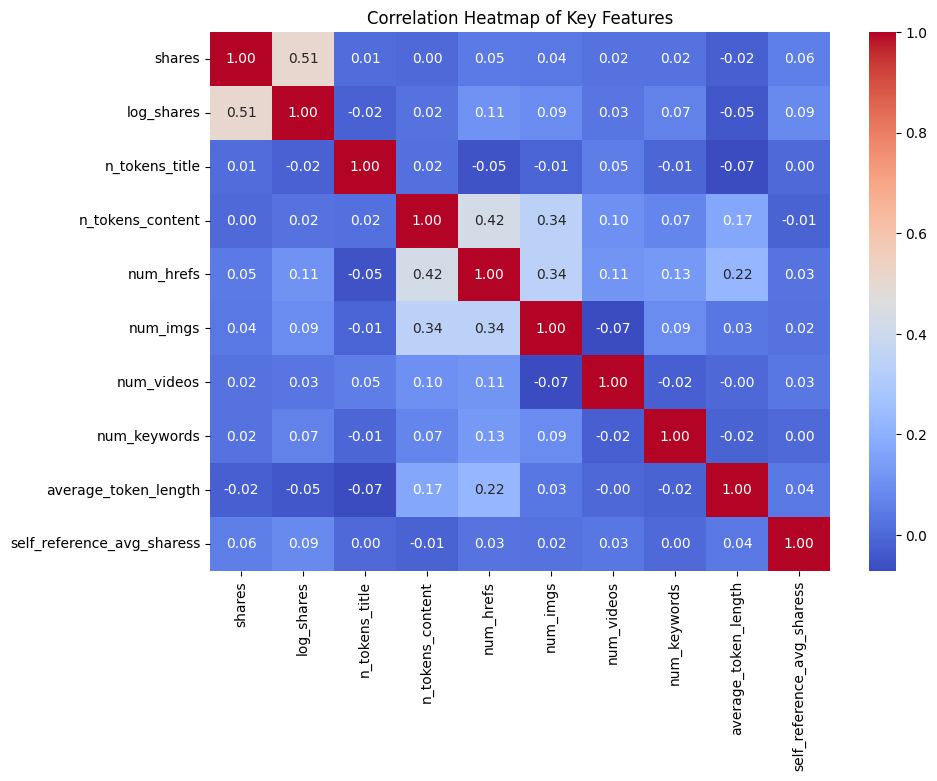

In [13]:
# Correlation heatmap
selected_cols = [
    "shares",
    "log_shares",
    "n_tokens_title",
    "n_tokens_content",
    "num_hrefs",
    "num_imgs",
    "num_videos",
    "num_keywords",
    "average_token_length",
    "self_reference_avg_sharess"
]

corr = df[selected_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Features")
plt.show()